In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import io as sio
import seaborn as sns 
from sklearn.preprocessing import LabelBinarizer , StandardScaler ,MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report , accuracy_score,ConfusionMatrixDisplay
from xgboost import XGBClassifier, plot_importance
from sklearn.linear_model import LogisticRegression , RidgeClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier 
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn import preprocessing
from sklearn.linear_model import LinearRegression
from numpy import absolute
from numpy import sqrt
from numpy import mean
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
import pandas as pd
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

from sklearn.utils import resample
from sklearn.ensemble import AdaBoostClassifier , GradientBoostingClassifier , VotingClassifier , RandomForestClassifier

In [2]:
data = pd.read_csv("Diabetes Dataset.csv")
data.head(10)

,PG,GL,BP,ST,IN,BMI,DPF,AG,DB
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1


In [3]:
data.tail()

,PG,GL,BP,ST,IN,BMI,DPF,AG,DB
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1
767,1,93,70,31,0,30.4,0.315,23,0


In [4]:
#Shape of Data
data.shape

(768, 9)

In [5]:
data['DB'].value_counts()

0    500
1    268
Name: DB, dtype: int64

In [6]:
#infromation of dataset
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   PG      768 non-null    int64  
 1   GL      768 non-null    int64  
 2   BP      768 non-null    int64  
 3   ST      768 non-null    int64  
 4   IN      768 non-null    int64  
 5   BMI     768 non-null    float64
 6   DPF     768 non-null    float64
 7   AG      768 non-null    int64  
 8   DB      768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [7]:
#lets describe the data
data.describe()

,PG,GL,BP,ST,IN,BMI,DPF,AG,DB
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [8]:
data.count()

PG     768
GL     768
BP     768
ST     768
IN     768
BMI    768
DPF    768
AG     768
DB     768
dtype: int64

In [9]:
#sns.pairplot(data)

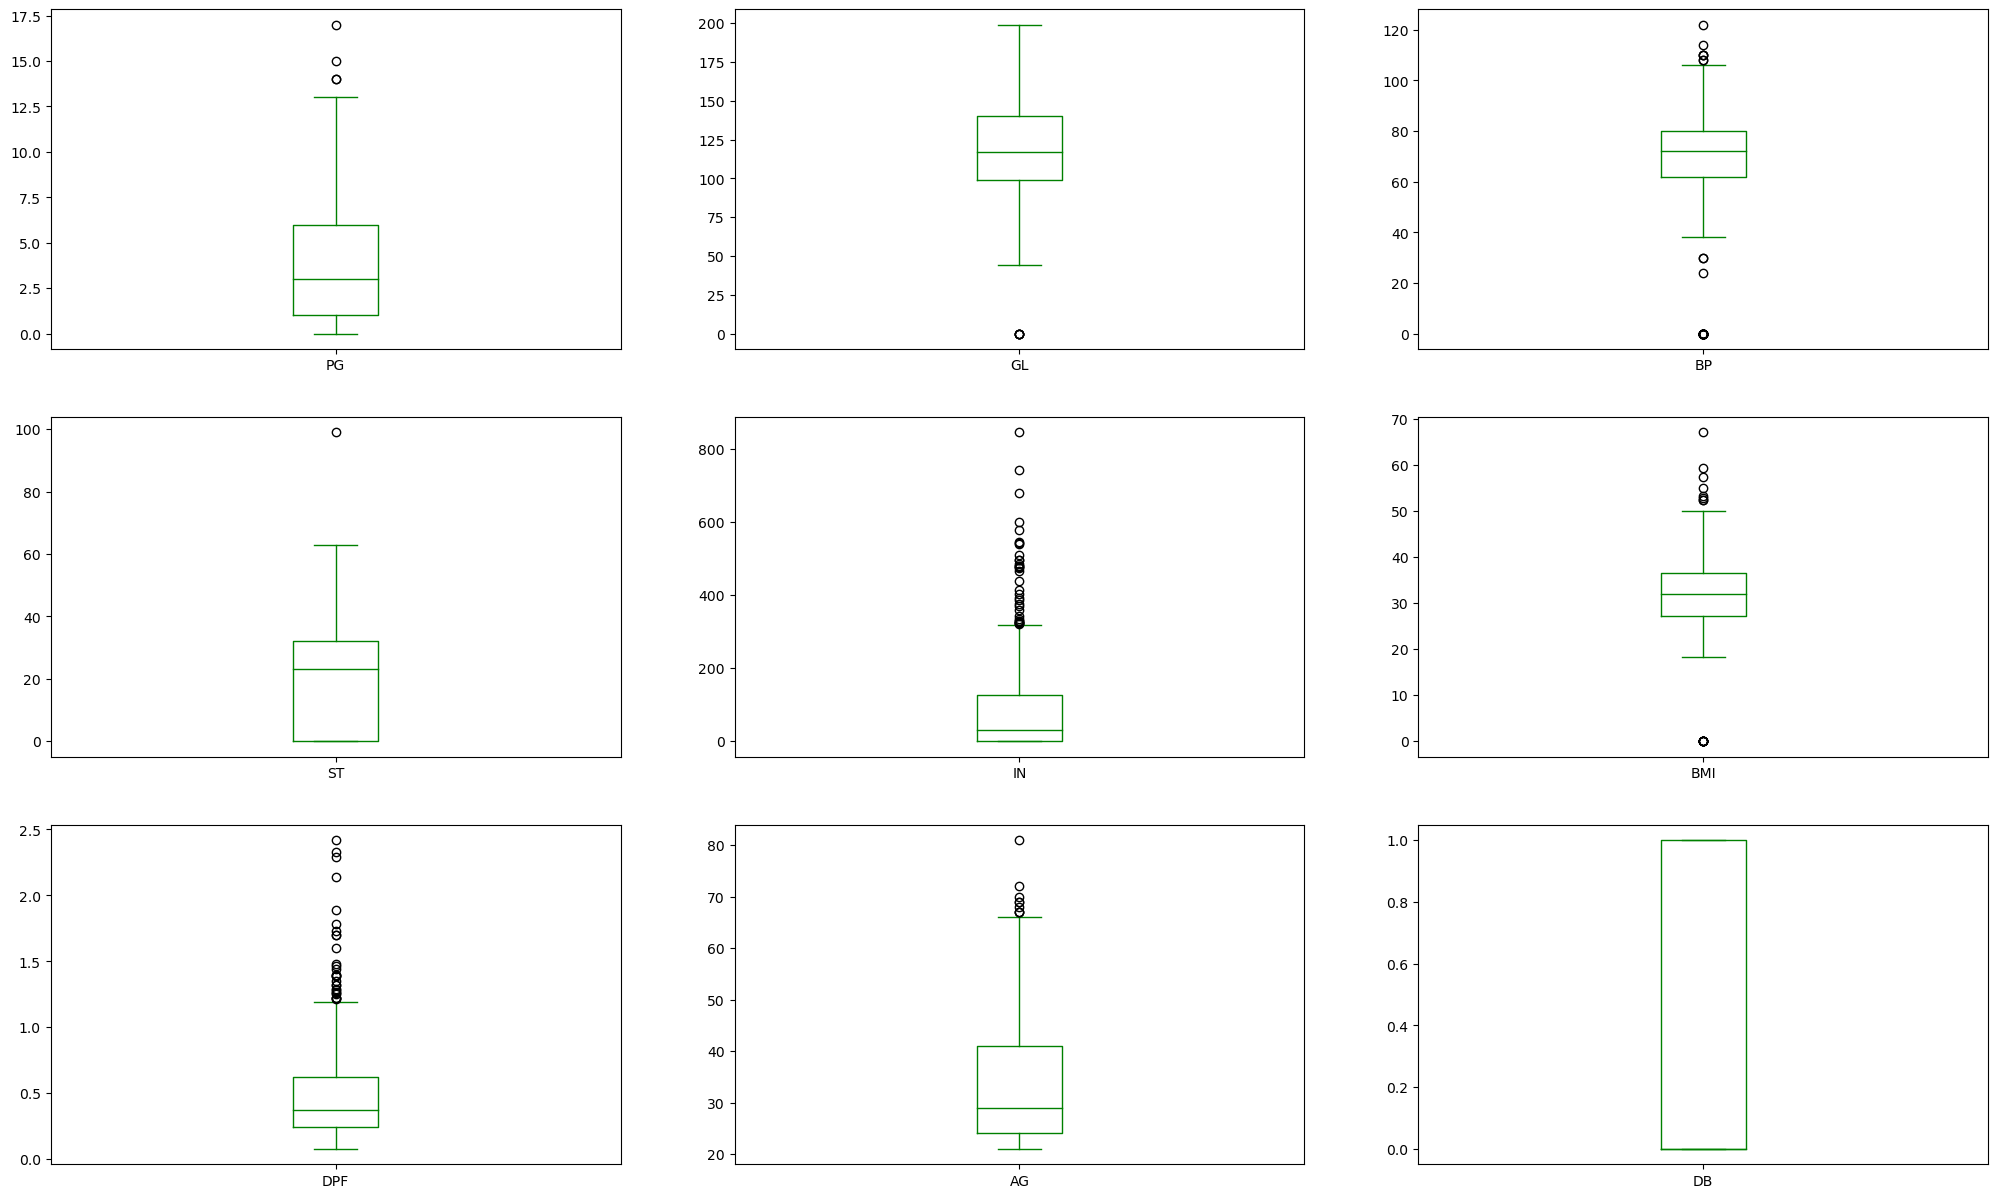

In [10]:
data.plot(color = 'g', kind='box', figsize=(25, 15), subplots=True, layout=(3,3))
plt.show()

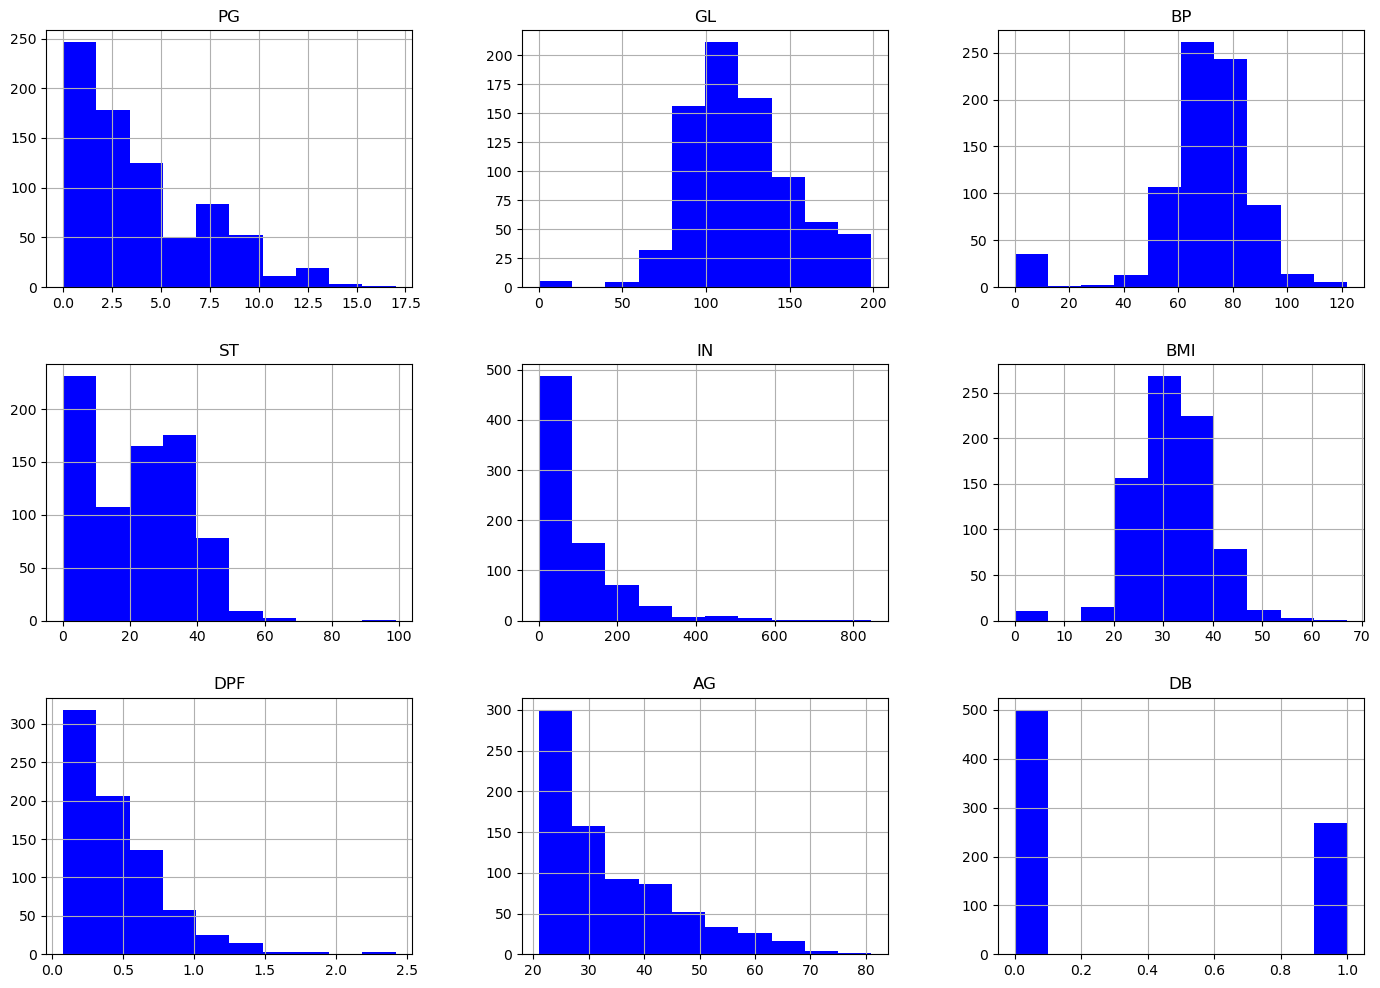

In [11]:
#histogram
data.hist(color='Blue',bins=10,figsize=(17,12))
plt.show()

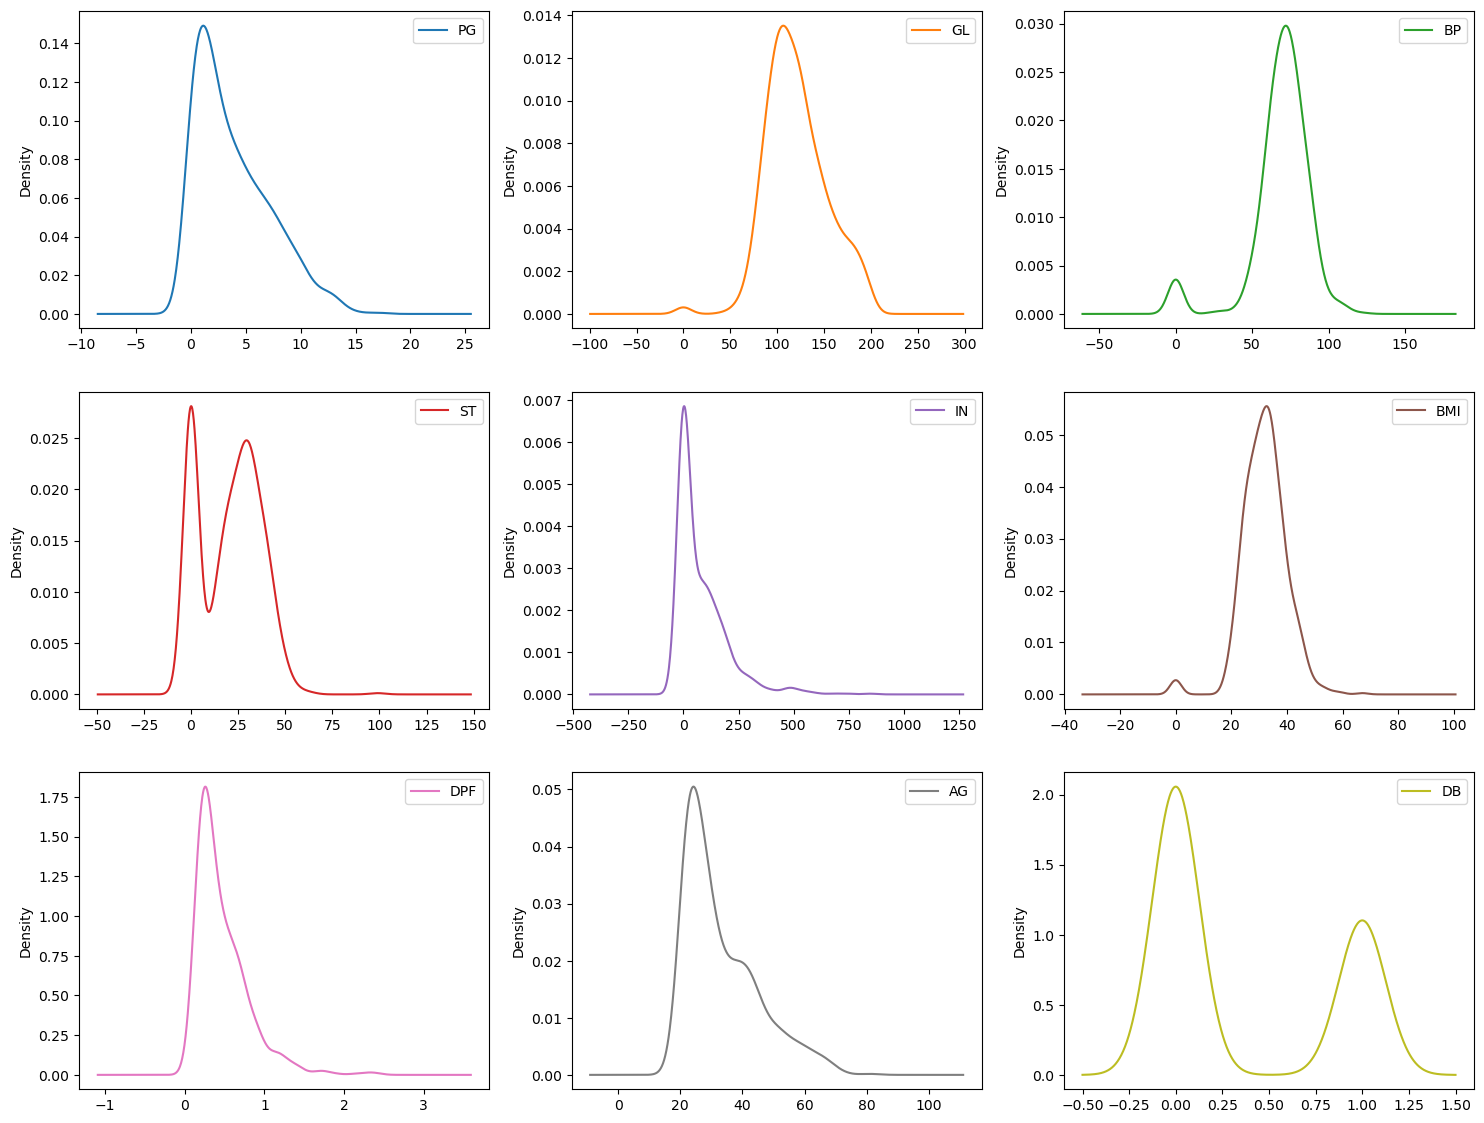

In [12]:
#Boxplot of each column
data.plot( kind='density', figsize=(18,14), subplots=True, layout=(3,3),sharex=False)
plt.show()

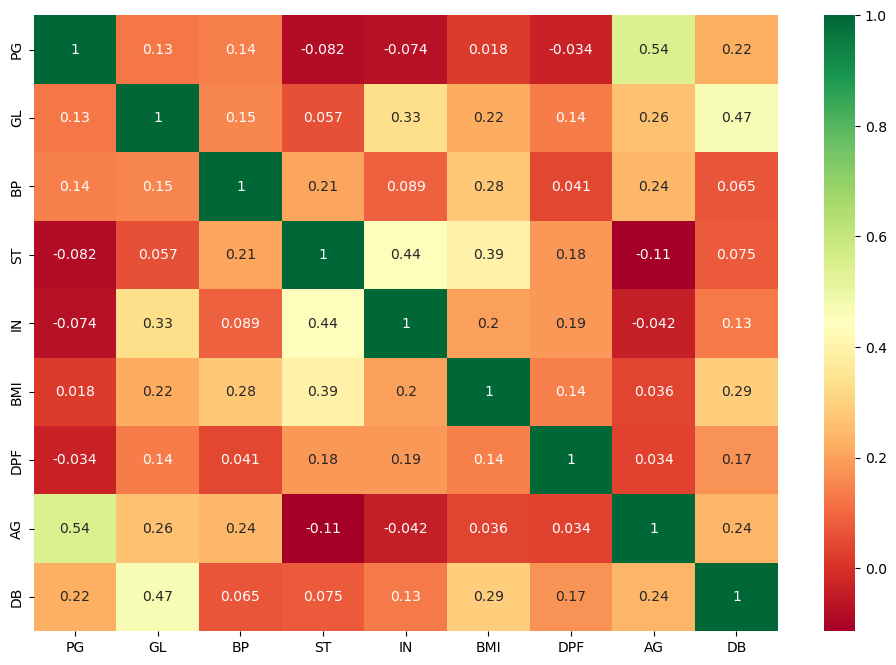

In [13]:
#get correlations of each features in dataset
corrmat = data.corr()
top_corr_features = corrmat.index
plt.figure(figsize=(12,8))
#plot heat map
g=sns.heatmap(data[top_corr_features].corr(),annot=True,cmap="RdYlGn")

In [14]:
#checking for the out layers with STD
print("Highest allowed",data['IN'].mean() + 3*data['IN'].std())
print("Lowest allowed",data['IN'].mean() - 3*data['IN'].std())

Highest allowed 425.53148622068176
Lowest allowed -265.9325278873484


In [15]:
#dealing with out layer values 
data[(data['IN'] > 270) | (data['IN'] < -266)]


,PG,GL,BP,ST,IN,BMI,DPF,AG,DB
8,2,197,70,45,543,30.5,0.158,53,1
13,1,189,60,23,846,30.1,0.398,59,1
53,8,176,90,34,300,33.7,0.467,58,1
54,7,150,66,42,342,34.7,0.718,42,0
56,7,187,68,39,304,37.7,0.254,41,1
111,8,155,62,26,495,34.0,0.543,46,1
139,5,105,72,29,325,36.9,0.159,28,0
144,4,154,62,31,284,32.8,0.237,23,0
153,1,153,82,42,485,40.6,0.687,23,0
162,0,114,80,34,285,44.2,0.167,27,0


In [16]:
new_df = data[(data['IN'] <270) & (data['IN'] >-266)]
new_df

,PG,GL,BP,ST,IN,BMI,DPF,AG,DB
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [17]:
#storing the values 
upper_limit = data['IN'].mean() + 3*data['IN'].std()
lower_limit = data['IN'].mean() - 3*data['IN'].std()

In [18]:
data['IN'] = np.where(
    data['IN']>upper_limit,
    upper_limit,
    np.where(
        data['IN']<lower_limit,
        lower_limit,
        data['IN']
    )
)

C:\Users\Shahid Mohammad\AppData\Local\Temp\ipykernel_21248\3300920682.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data['IN'])
C:\Users\Shahid Mohammad\AppData\Local\Temp\ipykernel_21248\3300920682.py:8: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(new_df['IN'])


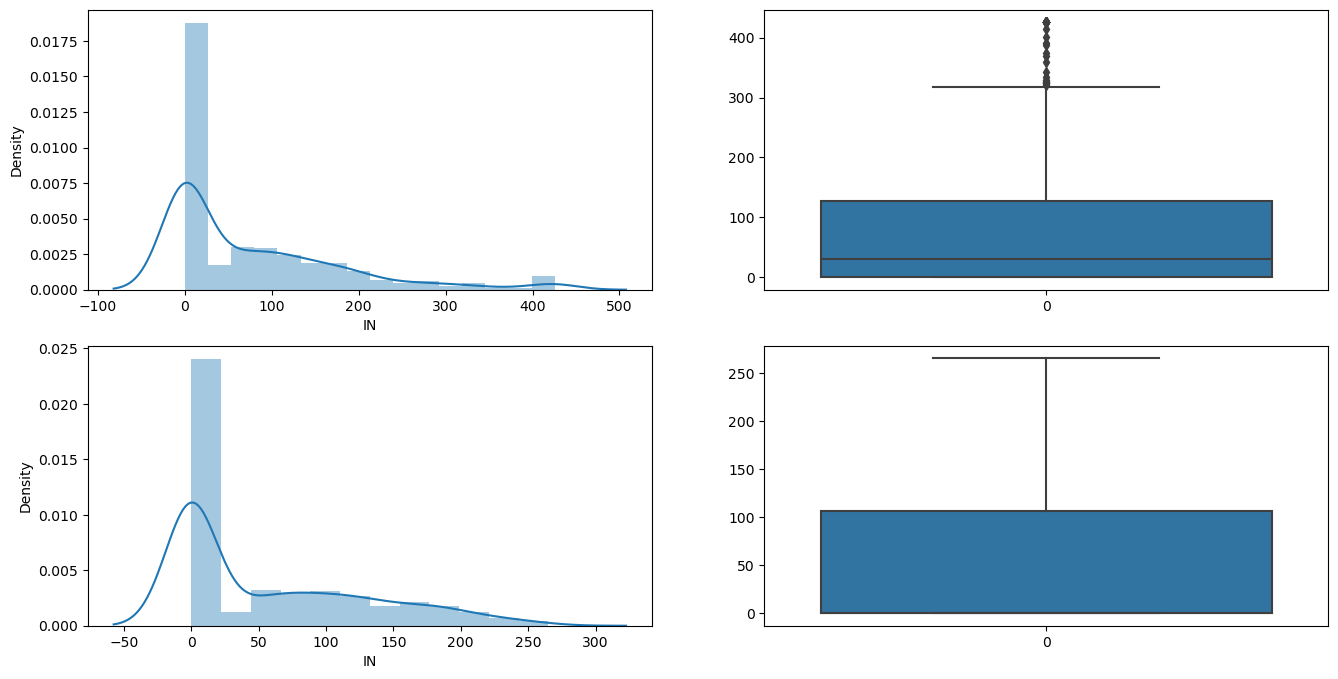

In [19]:
#ploting the outlayer removing 
plt.figure(figsize=(16,8))
plt.subplot(2,2,1)
sns.distplot(data['IN'])
plt.subplot(2,2,2)
sns.boxplot(data['IN'])
plt.subplot(2,2,3)
sns.distplot(new_df['IN'])
plt.subplot(2,2,4)
sns.boxplot(new_df['IN'])
plt.show()

In [20]:
# creating a for to replace outlayers using boxplot method
num_var=(data)
for i in num_var:
    # taking quantiles
    Q1 = data[i].quantile(0.25)
    Q3 = data[i].quantile(0.75)
    IQR = Q3 - Q1 # calculating IQR
    data[i] = np.where(data[i]>(Q3+1.5*IQR),(Q3+1.5*IQR),data[i]) # removing outlayers
    data[i] = np.where(data[i]<(Q1-1.5*IQR),(Q1-1.5*IQR),data[i]) # removing outlayers

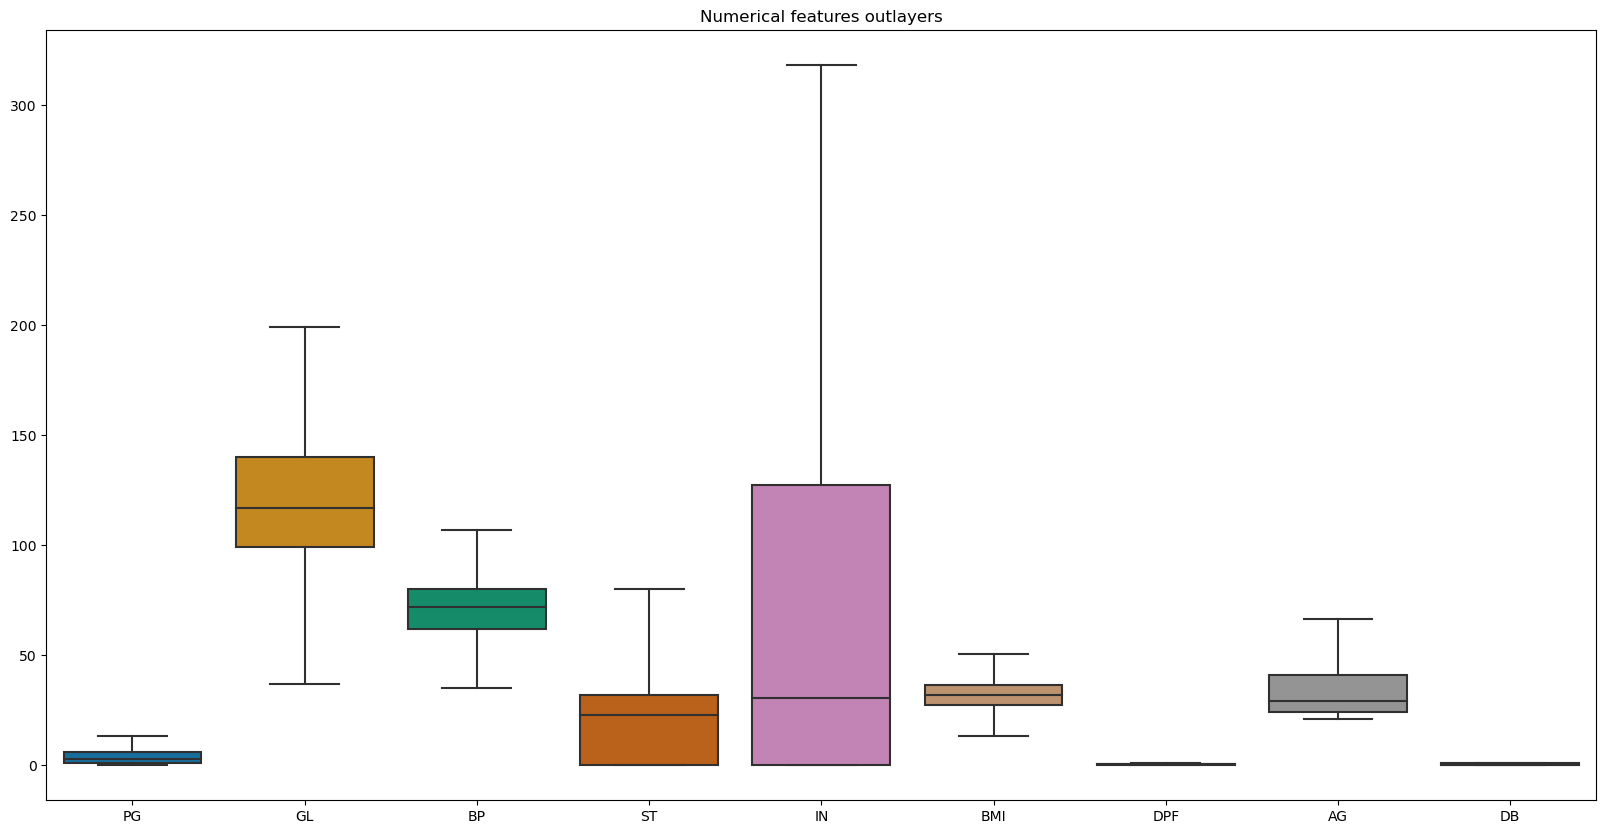

In [21]:
# Plotting boxplots to numeric features
num_var = ['PG','GL','BP','ST','IN','BMI','DPF','AG','DB']


plt.figure(figsize=(20,10))
sns.boxplot(data=data[num_var], 
                 palette="colorblind")
plt.title('Numerical features outlayers');

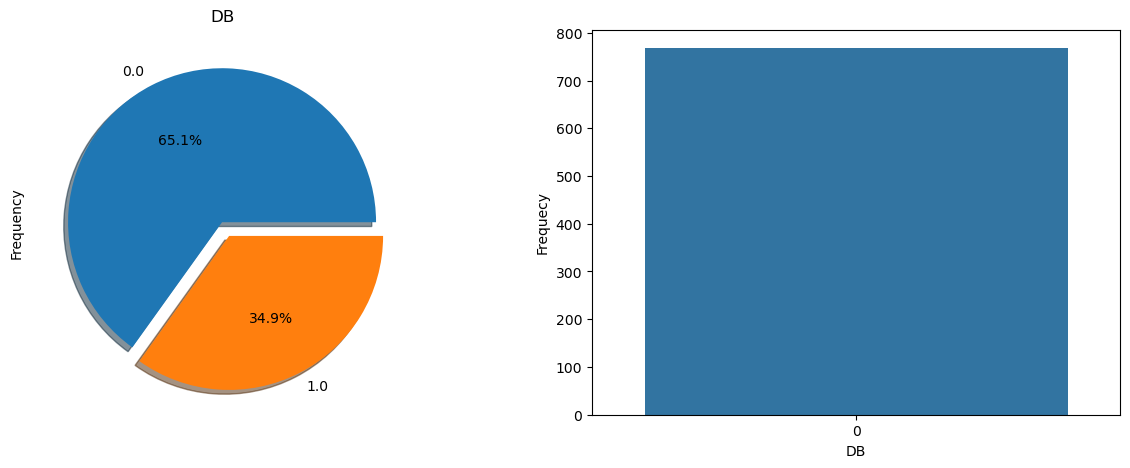

In [27]:
#Plot the diabetic Values
f,ax=plt.subplots(1,2,figsize=(15,5))
sns.countplot(data['DB'])
#plt.title("Frequency of Diabetes in Dataset")
plt.xlabel("DB")
plt.ylabel("Frequecy")

#Piechart show
data['DB'].value_counts().plot.pie(explode=[0,0.1],autopct='%1.1f%%',ax=ax[0],shadow=True)
ax[0].set_title('DB')
ax[0].set_ylabel('Frequency')
plt.show()

In [28]:
data.columns

Index(['PG', 'GL', 'BP', 'ST', 'IN', 'BMI', 'DPF', 'AG', 'DB'], dtype='object')

In [30]:
#reading data from pandas
col_names = ['PG', 'GL', 'BP', 'ST', 'IN', 'BMI', 'DPF', 'AG', 'DB']
df = pd.read_csv("Diabetes Dataset.csv", header=1, names=col_names)

<Axes: >

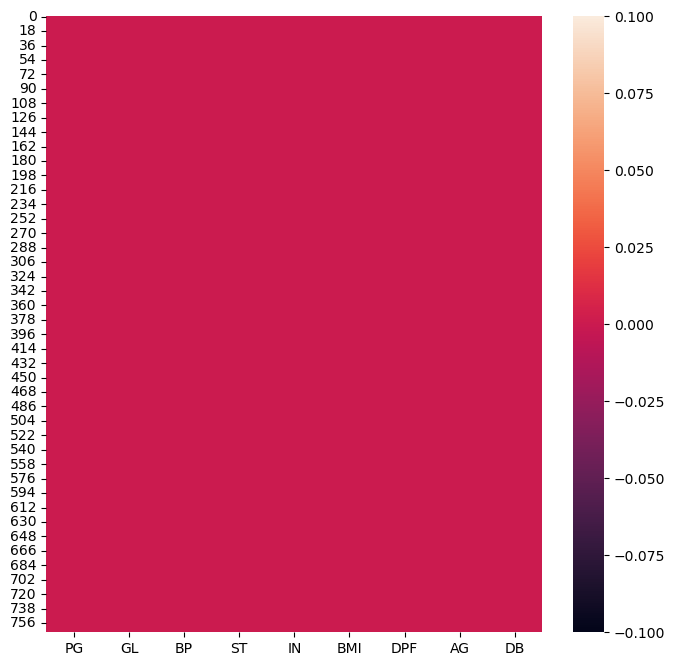

In [31]:
plt.figure(figsize=(8,8))
sns.heatmap(data.isnull())

In [32]:
data_boxcox = data.copy()
X = data_boxcox.drop(['DB'],axis=1)
Y = data_boxcox['DB']

In [33]:
#To keep BoxCox data as it is to use the same for later.
data_bal = data_boxcox.copy()

#Getting seperated data with 1 and 0 status.
df_majority = data_bal[data_bal.DB==0]
df_minority = data_bal[data_bal.DB==1]

#Here we are downsampling the Majority Class Data Points. 
#i.e. We will get equal amount of datapoint as Minority class from Majority class
df_manjority_downsampled = resample(df_majority,replace=False,n_samples=150,random_state=123)
df_downsampled = pd.concat([df_manjority_downsampled,df_minority])
print("Downsampled data:->\n",df_downsampled.DB.value_counts())

#Here we are upsampling the Minority Class Data Points. 
#i.e. We will get equal amount of datapoint as Majority class from Minority class
df_monority_upsampled = resample(df_minority,replace=True,n_samples=300,random_state=123)
df_upsampled = pd.concat([df_majority,df_monority_upsampled])
print("Upsampled data:->\n",df_upsampled.DB.value_counts())

Downsampled data:->
 1.0    268
0.0    150
Name: DB, dtype: int64
Upsampled data:->
 0.0    500
1.0    300
Name: DB, dtype: int64


Text(0.5, 0, 'DB')

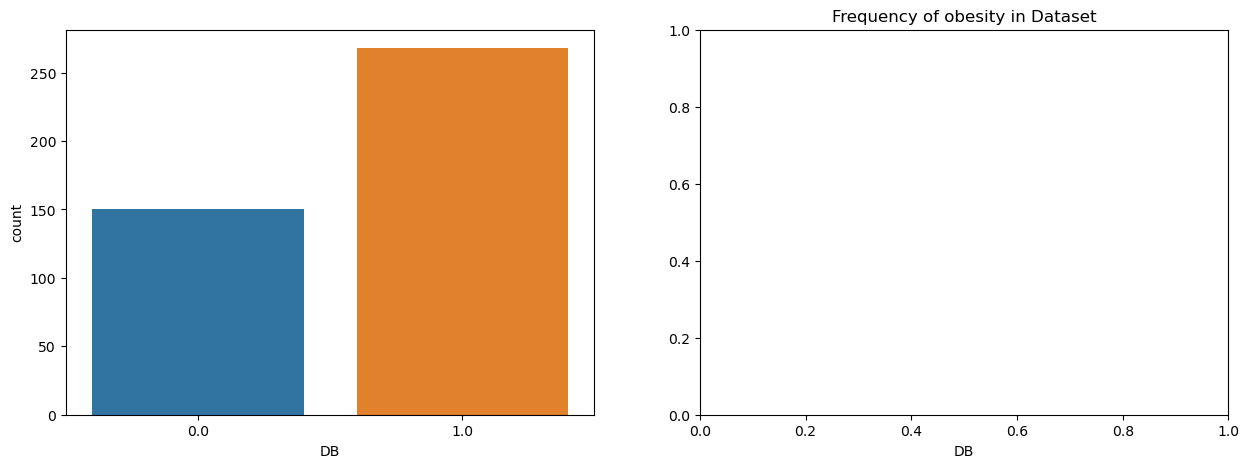

In [34]:
#Plot the diabetic Values
# f,ax=plt.subplots(1,2,figsize=(15,5))
# sns.countplot(df_downsampled['Outcome'])
# plt.title("Frequency of Heart Disease in Dataset")
# plt.xlabel("Outcome")
# plt.ylabel("Frequecy")

# #Piechart show
# df_downsampled['Outcome'].value_counts().plot.pie(explode=[0,0.1],autopct='%1.1f%%',ax=ax[0],shadow=True)
# ax[0].set_title('Outcome')
# ax[0].set_ylabel('Frequency')
# plt.show()
f,ax=plt.subplots(1,2,figsize=(15,5))
sns.countplot(x='DB', data=df_downsampled, ax=ax[0])
plt.title("Frequency of obesity in Dataset")
plt.xlabel("DB")

Text(0.5, 0, 'DB')

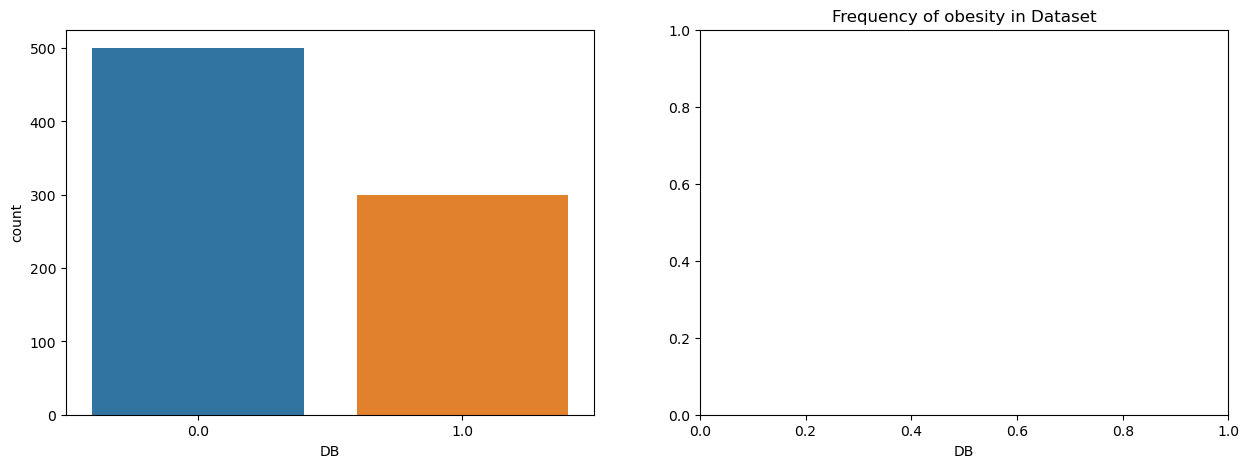

In [35]:
#Plot the diabetic Values
# f,ax=plt.subplots(1,2,figsize=(15,5))
# sns.countplot(df_upsampled['Outcome'])
# plt.title("Frequency of Heart Disease in Dataset")
# plt.xlabel("Outcome")
# plt.ylabel("Frequecy")
# #Piechart show
# df_upsampled['Outcome'].value_counts().plot.pie(explode=[0,0.1],autopct='%1.1f%%',ax=ax[0],shadow=True)
# ax[0].set_title('Outcome')
# ax[0].set_ylabel('Frequency')
# plt.show()
f,ax=plt.subplots(1,2,figsize=(15,5))
sns.countplot(x='DB', data=df_upsampled, ax=ax[0])
plt.title("Frequency of obesity in Dataset")
plt.xlabel("DB")

In [36]:
#lets describe the data
df_upsampled.describe().T

,count,mean,std,min,25%,50%,75%,max
PG,800.0,3.963750,3.381546,0.000,1.00,3.00,6.00000,13.500
GL,800.0,121.114531,30.882870,37.125,99.00,117.00,140.00000,199.000
BP,800.0,70.500000,14.061193,35.000,62.00,72.00,80.00000,107.000
ST,800.0,20.701250,15.575389,0.000,0.00,23.00,33.00000,60.000
IN,800.0,76.013281,92.713394,0.000,0.00,44.00,130.00000,318.125
BMI,800.0,32.076812,6.865989,13.350,27.40,32.05,36.12500,50.550
DPF,800.0,0.462776,0.288514,0.078,0.24,0.38,0.64625,1.200
AG,800.0,33.140625,11.390081,21.000,24.00,29.00,41.00000,66.500
DB,800.0,0.375000,0.484426,0.000,0.00,0.00,1.00000,1.000


In [37]:
#lets describe the data
df_downsampled.describe().T

,count,mean,std,min,25%,50%,75%,max
PG,418.0,4.287081,3.559885,0.000,1.00000,4.0000,7.000,13.500
GL,418.0,129.969498,33.001640,37.125,105.00000,126.0000,155.000,199.000
BP,418.0,71.784689,14.704493,35.000,64.00000,72.0000,80.000,107.000
ST,418.0,20.672249,16.431684,0.000,0.00000,24.0000,33.000,80.000
IN,418.0,81.081938,101.863372,0.000,0.00000,0.0000,145.750,318.125
BMI,418.0,33.288278,7.084671,13.350,28.75000,32.9000,37.575,50.550
DPF,418.0,0.498605,0.300495,0.085,0.25525,0.4215,0.686,1.200
AG,418.0,34.991627,11.801132,21.000,25.00000,32.0000,42.750,66.500
DB,418.0,0.641148,0.480238,0.000,0.00000,1.0000,1.000,1.000


In [40]:
from sklearn.metrics import confusion_matrix
import itertools
from sklearn.ensemble import AdaBoostRegressor
import xgboost as xgb

In [42]:
from sklearn import  metrics 
X = df_upsampled.drop(['DB'],axis=1)
classes = ["DB ", "No_DB "]
Y = df_upsampled['DB']
X_train , X_test , y_train , y_test = train_test_split(X,Y,test_size=0.20,random_state=0)

In [43]:
data.columns

Index(['PG', 'GL', 'BP', 'ST', 'IN', 'BMI', 'DPF', 'AG', 'DB'], dtype='object')

In [44]:
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import roc_curve
from sklearn.metrics import auc
from sklearn.metrics import precision_recall_curve

In [45]:
X = np.array(df_upsampled[['PG', 'GL', 'BP', 'ST', 'IN', 'BMI', 'DPF', 'AG', 'DB']])
Y = np.array(df_upsampled.DB.T)
X_train , X_test , y_train , y_test = train_test_split(X,Y,test_size=0.20,random_state=0)


models = []
models.append(("XGB",XGBClassifier()))
models.append(("ADB",AdaBoostClassifier()))
models.append(("GB",GradientBoostingClassifier()))
models.append(("LightGBM",LGBMClassifier()))
models.append(("Catboost",CatBoostClassifier()))

### GB

              precision    recall  f1-score   support

           0       0.91      0.94      0.92        97
           1       0.90      0.86      0.88        63

    accuracy                           0.91       160
   macro avg       0.91      0.90      0.90       160
weighted avg       0.91      0.91      0.91       160

0.90625


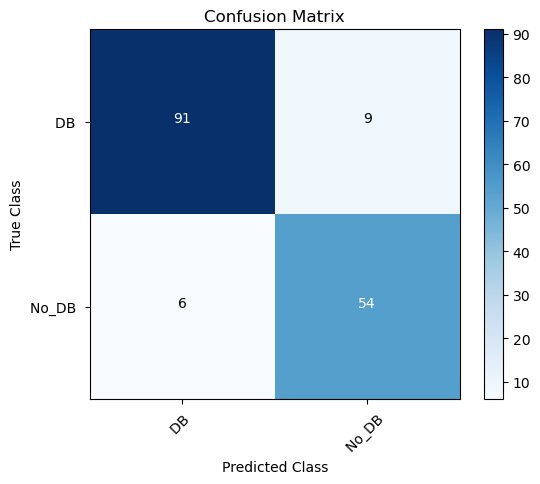

In [46]:
X = df_upsampled.drop(["DB"],axis=1)
Y = df_upsampled["DB"]
X_train , X_test , y_train , y_test = train_test_split(X,Y,test_size=0.20,random_state=0)
Model1 = GradientBoostingClassifier (learning_rate =0.1,n_estimators=100000,max_depth=6,min_child_weight=6,gamma=0,subsample=0.6,colsample_bytree=0.8,reg_alpha=0.005, objective= 'binary:logistic', nthread=2, scale_pos_weight=1, seed=27)

#(learning_rate =0.1,n_estimators=10000,max_depth=4,min_child_weight=6,gamma=0,subsample=0.6,colsample_bytree=0.8,reg_alpha=0.005, objective= 'binary:logistic', nthread=2, scale_pos_weight=1, seed=27)

Model1.fit(X_train,y_train)
y_pred = Model1.predict(X_test)
fpr_Model1, tpr_Model1, thresholds_Model1 = roc_curve(y_test, y_pred)
roc_auc_Model1 = auc (fpr_Model1, tpr_Model1)
precision_Model1, recall_Model1, th_Model1 = precision_recall_curve(y_test, y_pred)
print(classification_report(y_pred,y_test))
print(accuracy_score(y_pred,y_test))

#plot_confusion_matrix(Model1,X_test,y_test,display_labels=["LD","Non-LD"],cmap=plt.cm.Blues)
# Create a confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix
plt.imshow(cm, cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.colorbar()
tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes, rotation=45)
plt.yticks(tick_marks, classes)
plt.xlabel("Predicted Class")
plt.ylabel("True Class")

# Add labels to the plot
thresh = cm.max() / 2.
for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j, i, format(cm[i, j], 'd'),
             horizontalalignment="center",
             color="white" if cm[i, j] > thresh else "black")

In [47]:
#Features Importance Bar Plot
featur_names = ['PG', 'GL', 'BP', 'ST', 'IN', 'BMI', 'DPF', 'AG', 'DB']
features =Model1.feature_importances_
features

array([0.11710119, 0.12512623, 0.10985063, 0.10667017, 0.19379964,
       0.11928029, 0.11279558, 0.11537629], dtype=float32)

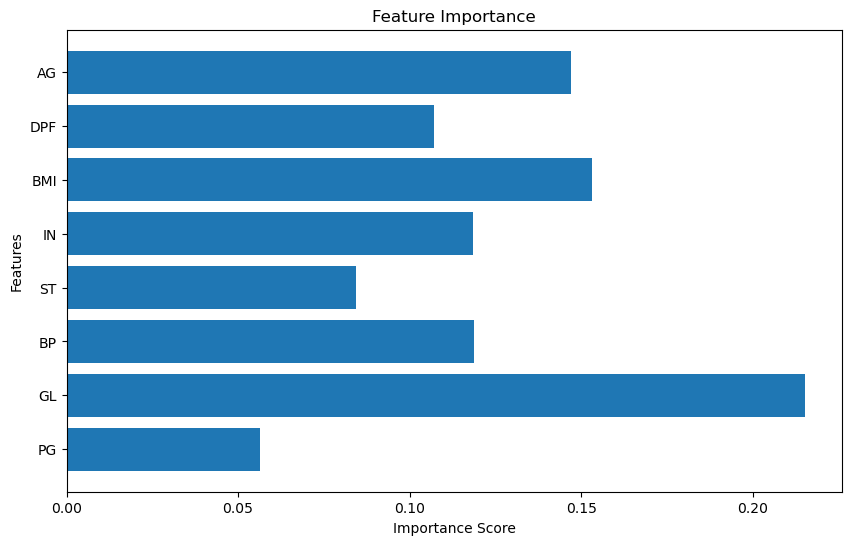

In [48]:
xgbr = xgb.XGBRegressor()
xgbr.fit(X_train, y_train)

# Get the feature importance scores
importance_scores = xgbr.feature_importances_
feature_names = X_train.columns

# Plot the feature importances
plt.figure(figsize=(10, 6))
plt.barh(feature_names, importance_scores)
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.title('Feature Importance')
plt.show()

# XAI

In [54]:
import shap
shap.initjs()

## SHAP

In [55]:
# Explain the model's predictions using SHAP
explainer = shap.Explainer(Model1.predict, X_train)
shap_values = explainer(X_test)

ExactExplainer explainer: 161it [00:26,  5.98it/s]                                                                     


In [56]:
np.shape(shap_values.values)

(160, 8)

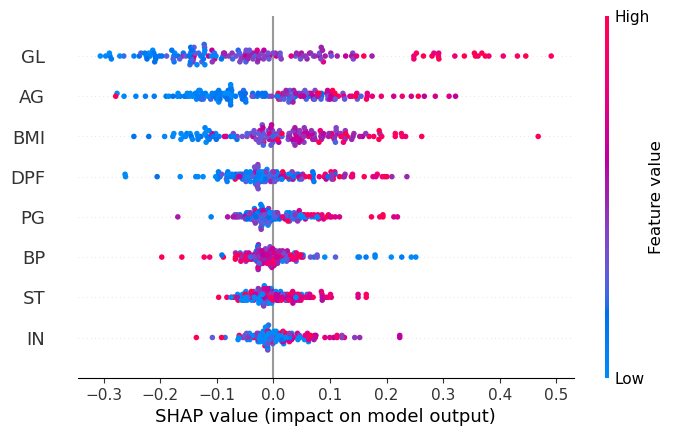

In [57]:
shap.plots.beeswarm(shap_values, max_display=len(shap_values.feature_names))

In [58]:
shap.plots.force(shap_values[100])

In [59]:
shap.plots.force(shap_values[0:100])

## LIME

In [60]:
#!pip install lime

import lime
import lime.lime_tabular

In [61]:
# Create a LimeTabularExplainer
explainer = lime.lime_tabular.LimeTabularExplainer(
    X.values,  # Use the NumPy array representation of X
    feature_names=X.columns.tolist(), # Feature names for interpretability
    class_names=['DB','NO_DB'], # Class names
    mode='classification' # or 'regression' depending on the task
)

In [62]:
# Choose an instance to explain
instance_index = 100 # Example: explain the instance
instance = X.iloc[instance_index]

In [63]:
# Explain the instance
explanation = explainer.explain_instance(
    instance.values,
    lambda x: Model1.predict_proba(pd.DataFrame(x, columns=X.columns)), # Use a lambda function to wrap the prediction
    num_features=15  # Number of features to show in explanation
)

In [64]:
# Show the explanation
explanation.show_in_notebook(show_table=True)

In [66]:
explanation.as_list()

[('GL <= 99.00', -0.21219854588502887),
 ('BMI <= 27.40', -0.16592661107197682),
 ('AG <= 24.00', -0.0981204033257805),
 ('44.00 < IN <= 130.00', -0.09203752026759252),
 ('BP <= 62.00', 0.039644250134542),
 ('0.00 < ST <= 23.00', -0.03863312185038829),
 ('1.00 < PG <= 3.00', -0.03010855524570324),
 ('0.38 < DPF <= 0.65', -0.018133944015703334)]